# **4. Modeling Dataset Preparation**

Now that `apps_eda` is fully cleaned and validated, we prepare the dataset for modeling.  
This section transforms the final application dataset into a model‑ready format by:

1. Defining the **target variable**  
2. Selecting the **correct feature columns**  
3. Creating **train–test splits**  
4. Building a preprocessing pipeline that:  
   - One‑Hot Encodes categorical variables  
   - Standard‑scales numeric variables  
   - Applies **cyclic encoding** for month‑of‑year  
5. Producing final encoded training and testing matrices

---

## **4.1 Define Target and Feature Set**

We use `target_default` as the modeling target.  
To avoid leakage, we exclude:

- `application_id` → identifier  
- `outcome_status` → used to derive the target  
- Any text‑based or raw columns removed earlier  
- The original `origination_month` datetime column  

We instead extract **year**, **month number**, and apply **cyclic encoding** to capture seasonality.

In [2]:
import pandas as pd 
import numpy as np

apps_eda = pd.read_csv('../data/apps_eda.csv')
apps_eda.head()

,requested_amount_usd,repayment_term,monthly_installment_usd,risk_grade_detail,employment_tenure,housing_status,annual_income_usd,income_verification_status,origination_month,loan_purpose,region_code,debt_to_income_ratio,credit_score_low,credit_score_high,open_credit_lines,public_records_count,interest_rate,revolving_utilization,target_default
0,18000.0,60 months,412.61,C3,3 years,own,105000.0,verified,2015-02-01,debt_consolidation,az,6.78,670.0,674.0,7.0,0.0,13.33,89.5,0
1,1000.0,36 months,33.21,C1,1 year,rent,28500.0,not verified,2016-04-01,home_improvement,fl,11.54,690.0,694.0,3.0,1.0,11.99,13.3,0
2,21275.0,36 months,696.42,B4,5 years,mortgage,130000.0,verified,2015-09-01,debt_consolidation,pa,23.08,680.0,684.0,13.0,0.0,10.99,75.7,0
3,35000.0,60 months,869.66,D3,10+ years,mortgage,107000.0,verified,2015-09-01,credit_card,sc,16.30,710.0,714.0,10.0,0.0,16.99,76.5,0
4,17000.0,60 months,427.73,D4,8 years,rent,55000.0,verified,2015-04-01,credit_card,ca,31.27,680.0,684.0,8.0,0.0,17.57,62.5,1


In [3]:

# 4.1 DEFINE TARGET AND FEATURE SET (REAL DATA)


import numpy as np
import pandas as pd
import os
import pickle

# Copy the cleaned dataset
df = apps_eda.copy()


# Ensure origination_month is datetime

apps_eda["origination_month"] = pd.to_datetime(apps_eda["origination_month"])


# Target variable

target = "target_default"


# Remove leakage / unused columns

drop_cols = [
    "origination_month"   # replaced by engineered features
]

df = df.drop(columns=drop_cols)


# Extract year + month number from origination_month


df["origination_year"] = apps_eda["origination_month"].dt.year
df["origination_month_num"] = apps_eda["origination_month"].dt.month


# Cyclic encoding for month-of-year


df["month_sin"] = np.sin(2 * np.pi * df["origination_month_num"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["origination_month_num"] / 12)


# Final feature list


feature_cols = [
    col for col in df.columns
    if col not in [target]
]

X = df[feature_cols]
y = df[target]

print("Number of features:", len(feature_cols))
print("Features:", feature_cols)



# 4.2 CREATE MODELS FOLDER AND SAVE X, y


# Create folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save X and y as pickle files
with open("models/X.pkl", "wb") as f:
    pickle.dump(X, f)

with open("models/y.pkl", "wb") as f:
    pickle.dump(y, f)

print("Saved X and y to /models/")


Number of features: 21
Features: ['requested_amount_usd', 'repayment_term', 'monthly_installment_usd', 'risk_grade_detail', 'employment_tenure', 'housing_status', 'annual_income_usd', 'income_verification_status', 'loan_purpose', 'region_code', 'debt_to_income_ratio', 'credit_score_low', 'credit_score_high', 'open_credit_lines', 'public_records_count', 'interest_rate', 'revolving_utilization', 'origination_year', 'origination_month_num', 'month_sin', 'month_cos']
Saved X and y to /models/


# **4.2 Dataset Preparation for Model Families**

To optimize our dataset for different modeling approaches, we create two versions:

- **X_lineal**:  
  - Designed for linear models (e.g., Logistic Regression).  
  - Keeps `month_sin` and `month_cos` to capture cyclical seasonality.  
  - Drops `origination_month_num`.  
  - Applies one-hot encoding to categorical variables.  
  - Scales all numeric features using `StandardScaler` to ensure balanced feature magnitudes.

- **X_tree**:  
  - Designed for tree-based models (e.g., Random Forest, XGBoost).  
  - Keeps `origination_month_num` as categorical.  
  - Drops `month_sin` and `month_cos`.  
  - Applies one-hot encoding to categorical variables.  
  - Leaves numeric features unscaled, since tree models are insensitive to feature magnitude.

Both datasets are saved in the `../data/` folder as `X_lineal.csv` and `X_tree.csv`.


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# --- X_lineal ---
X_lineal = X.drop(columns=['origination_month_num'])
X_lineal = pd.get_dummies(
    X_lineal,
    columns=['repayment_term', 'risk_grade_detail', 'employment_tenure',
             'housing_status', 'income_verification_status', 'loan_purpose',
             'region_code', 'origination_year'],
    drop_first=True
)

# Scale numeric features for logistic regression
numeric_cols = X_lineal.select_dtypes(include=['float64', 'int32']).columns
scaler = StandardScaler()
X_lineal[numeric_cols] = scaler.fit_transform(X_lineal[numeric_cols])

# Save
X_lineal.to_csv('../data/X_lineal.csv', index=False)

# --- X_tree ---
X_tree = X.drop(columns=['month_sin', 'month_cos'])
X_tree = pd.get_dummies(
    X_tree,
    columns=['repayment_term', 'risk_grade_detail', 'employment_tenure',
             'housing_status', 'income_verification_status', 'loan_purpose',
             'region_code', 'origination_year', 'origination_month_num'],
    drop_first=True
)

# Save
X_tree.to_csv('../data/X_tree.csv', index=False)


In [5]:
X_lineal.shape, X_tree.shape

((85000, 125), (85000, 134))

## **4.3 Create X_lineal.pkl from Encoded CSV**

Before performing PCA, we must convert the encoded feature matrix stored in  
`data/X_lineal.csv` into a serialized pickle object.  
This ensures the matrix can be loaded efficiently for PCA and modeling.

The following code loads the CSV, converts it into a numeric matrix,  
and saves it as `X_lineal.pkl` inside the `models/` folder.


In [16]:

# 4.3 CREATE X_lineal.pkl FROM ENCODED CSV 


import pandas as pd
import pickle
import os

# Load encoded linear feature matrix
X_lineal = pd.read_csv("../data/X_lineal.csv")

print("Loaded X_lineal.csv with shape:", X_lineal.shape)

# Ensure models folder exists
os.makedirs("models", exist_ok=True)

# Save as pickle
with open("models/X_lineal.pkl", "wb") as f:
    pickle.dump(X_lineal, f)

print("Saved X_lineal.pkl to models/")


Loaded X_lineal.csv with shape: (85000, 125)
Saved X_lineal.pkl to models/


## **4.4 PCA Component Interpretation**

Principal Component Analysis (PCA) transforms the original feature space into a new set of orthogonal components.  
Each component is a linear combination of the original variables, weighted by coefficients called **loadings**.

Understanding PCA components helps us:

- Identify which original features contribute most to each principal component  
- Detect groups of correlated variables  
- Understand latent structure in the dataset  
- Decide how many components to keep for modeling  
- Interpret what each component represents (e.g., “credit utilization”, “income strength”, “loan size”)  

### **What PCA Loadings Mean**

- A **high positive loading** means the feature contributes strongly in the positive direction.  
- A **high negative loading** means the feature contributes strongly in the negative direction.  
- A **near‑zero loading** means the feature has little influence on that component.  

By examining the loadings matrix, we can understand:

- Which features dominate each component  
- Whether components represent financial stress, credit behavior, loan characteristics, etc.  
- Whether PCA is capturing meaningful structure or just noise  

### **Why Interpretation Matters**

Even though PCA is unsupervised, interpreting components helps us:

- Validate that PCA is capturing real economic/credit patterns  
- Decide whether PCA‑based models are appropriate  
- Understand how dimensionality reduction affects model behavior  
- Communicate results to stakeholders  


## **4.5 PCA Component Interpretation**

This code loads the newly created `X_lineal.pkl`, scales it, fits PCA,  
and visualizes the loadings using a heatmap.  
It also prints the top contributing features for each component.


In [ ]:

# 4.5 PCA COMPONENT INTERPRETATION 


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pickle


# Load encoded dataset

with open("../python/models/X_lineal.pkl", "rb") as f:
    X_lineal = pickle.load(f)

with open("../python/models/y.pkl", "rb") as f:
    y = pickle.load(f)

print("Shape of X_lineal:", X_lineal.shape)


# Scale data before PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_lineal)


# Fit PCA on full scaled dataset

pca_full = PCA(n_components=None)
pca_full.fit(X_scaled)


# Create synthetic feature names

feature_names = [f"feat_{i}" for i in range(X_lineal.shape[1])]


# Build loadings matrix

loadings = pd.DataFrame(
    pca_full.components_,
    columns=feature_names
)



Shape of X_lineal: (85000, 125)


## **4.6 PCA Visualization Suite**

This section provides a complete visualization suite for PCA analysis, including:

- Explained variance for the first 60 components  
- Cumulative explained variance with a 95% threshold  
- A custom scatter‑style correlation heatmap for numeric features  

These plots help us understand how PCA distributes variance across components and how the original numeric variables relate to each other.


In [21]:

# 4.6 PCA VISUALIZATION SUITE


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pickle


# Load encoded dataset

with open("../python/models/X_lineal.pkl", "rb") as f:
    X_lineal = pickle.load(f)

with open("../python/models/y.pkl", "rb") as f:
    y = pickle.load(f)

print("Shape of X_lineal:", X_lineal.shape)


# Scale data before PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_lineal)


# Fit PCA

pca = PCA(n_components=None)
pca.fit(X_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

Shape of X_lineal: (85000, 125)


### 4.6.1. Explained Variance First 60 Components (Bar Plot)

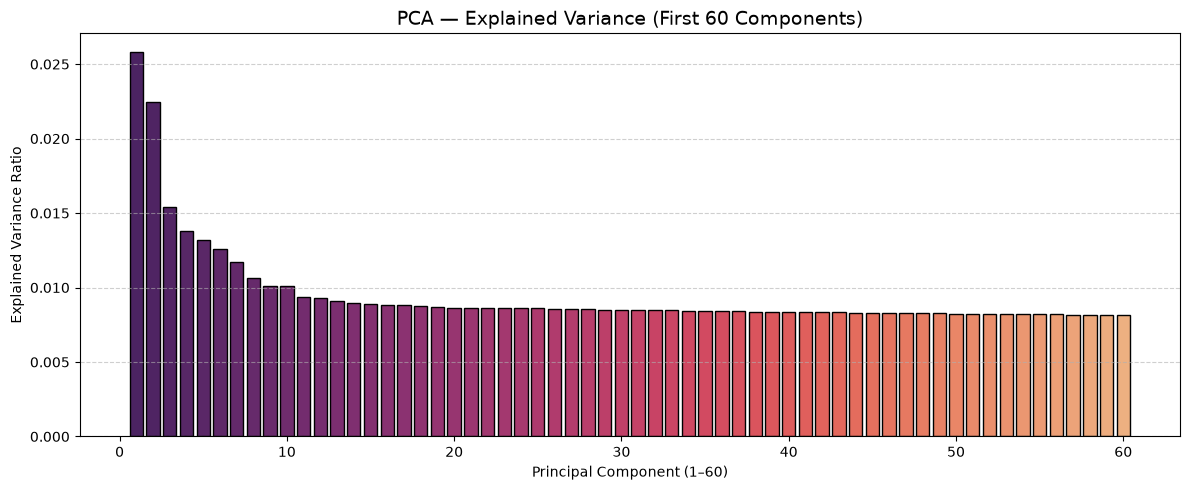

In [ ]:
# PCA Explained Variance — First 60 Components (Cubehelix Colors)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create cubehelix colormap
cube_cmap = sns.color_palette("flare_r", as_cmap=True)

# Generate colors for each bar
colors = cube_cmap(np.linspace(0, 1, 60))

plt.figure(figsize=(12,5))
plt.bar(
    range(1, 61),
    explained_var[:60],
    color=colors,
    edgecolor='black'
)

plt.xlabel("Principal Component (1–60)")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA  Explained Variance (First 60 Components)", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 4.6.2. Cumulative Explained Variance (Clean Line Plot)

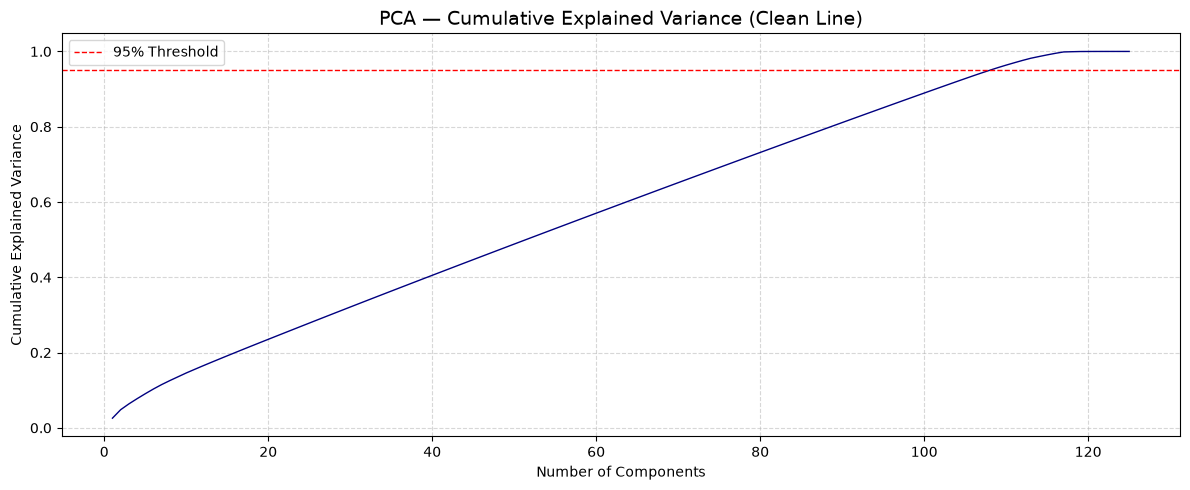

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, linewidth=1, color='navy')
plt.axhline(0.95, color='red', linestyle='--', linewidth=1, label='95% Threshold')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA  Cumulative Explained Variance (Clean Line)", fontsize=14)
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 4.6.3 PCA Loadings Scatter‑Heatmap

To visualize how each original encoded feature contributes to each principal component,  
we build a scatter‑style heatmap where:

- **Color** represents the PCA loading value  
- **Size** represents the absolute loading strength  
- **X‑axis** = original encoded features  
- **Y‑axis** = PCA components  

This visualization helps identify which features dominate each component and reveals  
latent structure captured by PCA.


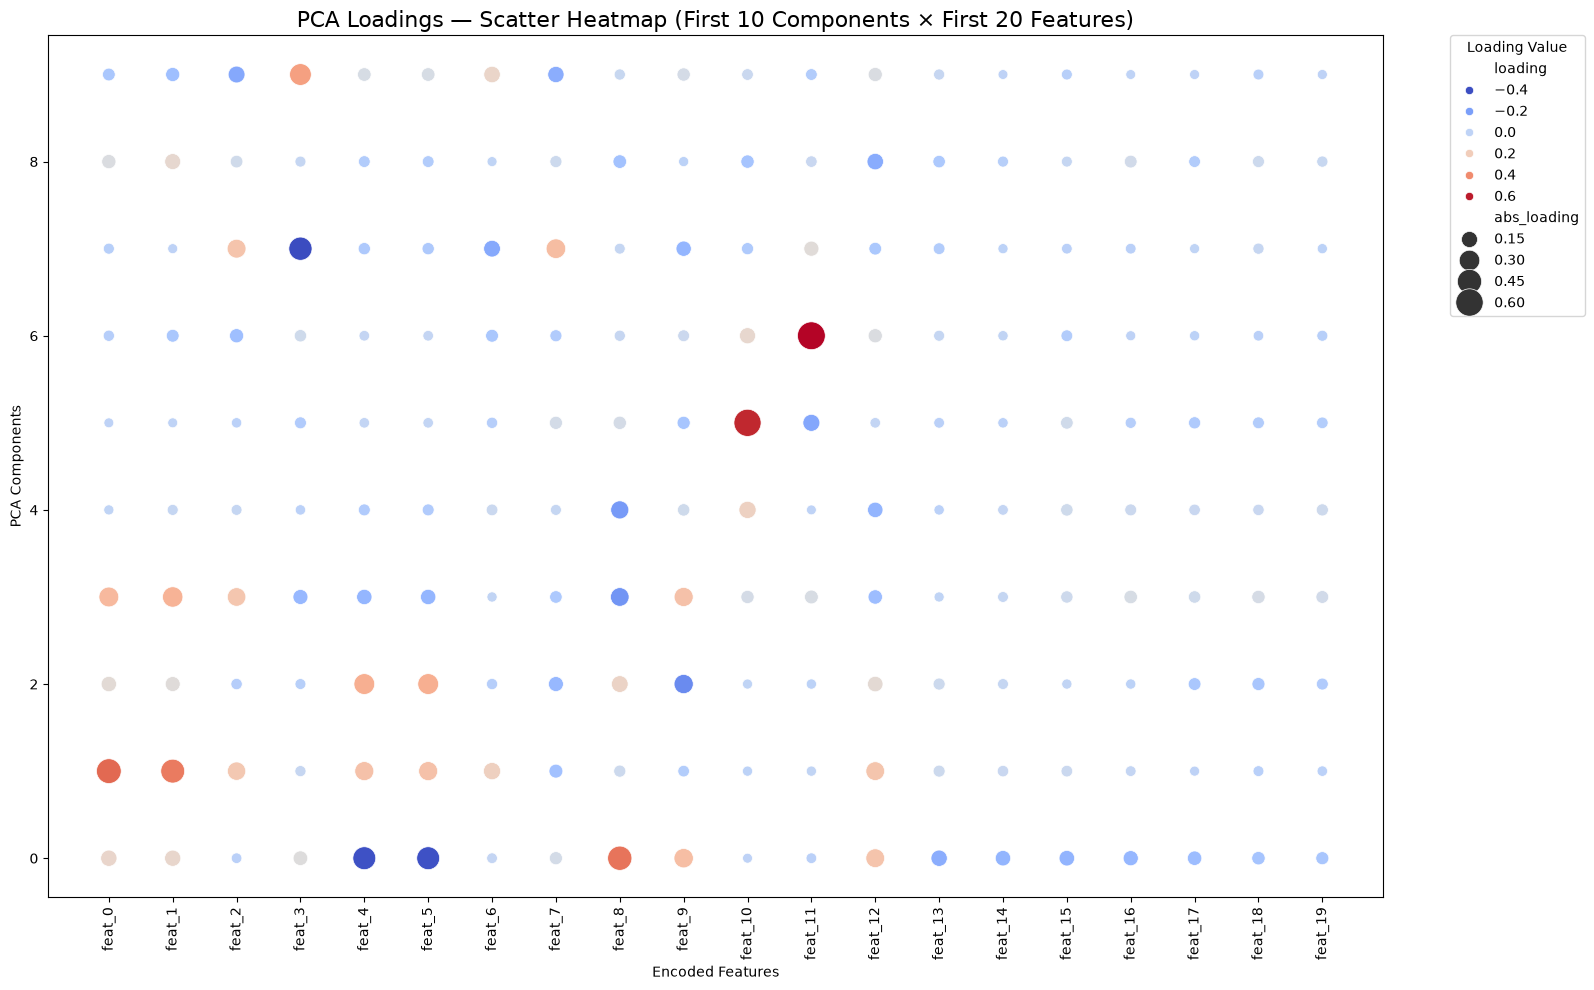

In [25]:

# Build loadings matrix

feature_names = [f"feat_{i}" for i in range(X_lineal.shape[1])]
loadings = pd.DataFrame(pca.components_, columns=feature_names)


# Select first 10 components × first 20 features

loadings_subset = loadings.iloc[:10, :20]

# Melt for scatter-style heatmap
loadings_melt = loadings_subset.reset_index().melt(id_vars='index')
loadings_melt.columns = ['component', 'feature', 'loading']
loadings_melt['abs_loading'] = loadings_melt['loading'].abs()


# Custom colormap

cmap = sns.color_palette("coolwarm", as_cmap=True)

plt.figure(figsize=(16, 10))

ax = sns.scatterplot(
    data=loadings_melt,
    x="feature",
    y="component",
    hue="loading",
    size="abs_loading",
    sizes=(50, 400),
    palette=cmap,
    edgecolor="white",
    linewidth=0.5,
    legend="brief"
)

plt.xticks(rotation=90)
plt.xlabel("Encoded Features")
plt.ylabel("PCA Components")
plt.title("PCA Loadings — Scatter Heatmap (First 10 Components × First 20 Features)", fontsize=16)

# Move legend outside
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0,
    title="Loading Value"
)

plt.tight_layout()
plt.show()


### 4.6.4 Create PCA‑Reduced Dataset (95% Variance)

In [35]:

# 4.3.8 CREATE PCA-REDUCED DATASET (95% VARIANCE)


import numpy as np
import pandas as pd
import pickle
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load encoded dataset

with open("../python/models/X_lineal.pkl", "rb") as f:
    X_lineal = pickle.load(f)

print("Original X_lineal shape:", X_lineal.shape)

# Scale data before PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_lineal)

# Fit PCA (all components first)

pca_full = PCA(n_components=None)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Determine number of components for 95% variance

n_components_95 = np.argmax(cumulative_var >= 0.95) + 1

print(f"Number of PCA components explaining 95% variance: {n_components_95}")

# Fit PCA again with optimal number of components

pca_95 = PCA(n_components=n_components_95)
X_lineal_pca = pca_95.fit_transform(X_scaled)

print("New PCA-reduced shape:", X_lineal_pca.shape)

# Ensure folders exist

os.makedirs("models", exist_ok=True)
os.makedirs("data", exist_ok=True)

# Save PCA dataset as pickle

with open("models/X_lineal_pca.pkl", "wb") as f:
    pickle.dump(X_lineal_pca, f)

# Save PCA dataset as CSV

pd.DataFrame(X_lineal_pca).to_csv("../data/X_lineal_pca.csv", index=False)

print("Saved PCA-reduced dataset to:")
print(" → models/X_lineal_pca.pkl")
print(" → data/X_lineal_pca.csv")


Original X_lineal shape: (85000, 125)
Number of PCA components explaining 95% variance: 108
New PCA-reduced shape: (85000, 108)
Saved PCA-reduced dataset to:
 → models/X_lineal_pca.pkl
 → data/X_lineal_pca.csv


# **4.7 PCA Analysis for X_tree**

Before applying machine‑learning models, it’s often useful to understand how much of the dataset’s structure can be captured using a smaller number of dimensions. Principal Component Analysis (PCA) helps us do exactly that.

In this section, we extend our dimensionality‑reduction workflow to the **X_tree** dataset. While tree‑based models do not require feature scaling or PCA to perform well, analyzing the variance structure of the dataset still provides valuable insight into how complex the feature space is and how many components are needed to summarize most of the information.

We begin by standardizing the data and fitting PCA across all components. Then we compute the **cumulative explained variance**, which shows how quickly PCA captures the dataset’s variability. The goal is to identify the number of principal components required to explain **95% of the variance**, a common threshold in data science for balancing dimensionality reduction with information retention.

Finally, we visualize the cumulative explained variance using a clean line plot and save both the original and PCA‑reduced datasets (`X_tree.pkl` and `X_tree_pca.pkl`) into the `models/` directory for future modeling steps.


In [6]:
#  PCA ANALYSIS FOR X_tree DATASET

import numpy as np
import pandas as pd
import pickle
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load raw X_tree dataset 

print("Shape of X_tree:", X_tree.shape)

# Save original X_tree dataset as pickle

os.makedirs("models", exist_ok=True)

with open("models/X_tree.pkl", "wb") as f:
    pickle.dump(X_tree, f)

print("Saved original dataset to models/X_tree.pkl")

# Scale data before PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tree)

# Fit PCA (all components)

pca_full = PCA(n_components=None)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Determine number of components for 95% variance

n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"Number of PCA components explaining 95% variance: {n_components_95}")

# Fit PCA again with optimal number of components
pca_95 = PCA(n_components=n_components_95)
X_tree_pca = pca_95.fit_transform(X_scaled)

print("New PCA-reduced shape:", X_tree_pca.shape)

# ------------------------------------------------------------
# Save PCA dataset as pickle
# ------------------------------------------------------------
with open("models/X_tree_pca.pkl", "wb") as f:
    pickle.dump(X_tree_pca, f)

print("Saved PCA-reduced dataset to models/X_tree_pca.pkl")

Shape of X_tree: (85000, 134)
Saved original dataset to models/X_tree.pkl


Number of PCA components explaining 95% variance: 116
New PCA-reduced shape: (85000, 116)
Saved PCA-reduced dataset to models/X_tree_pca.pkl


### Plot cumulative explained variance

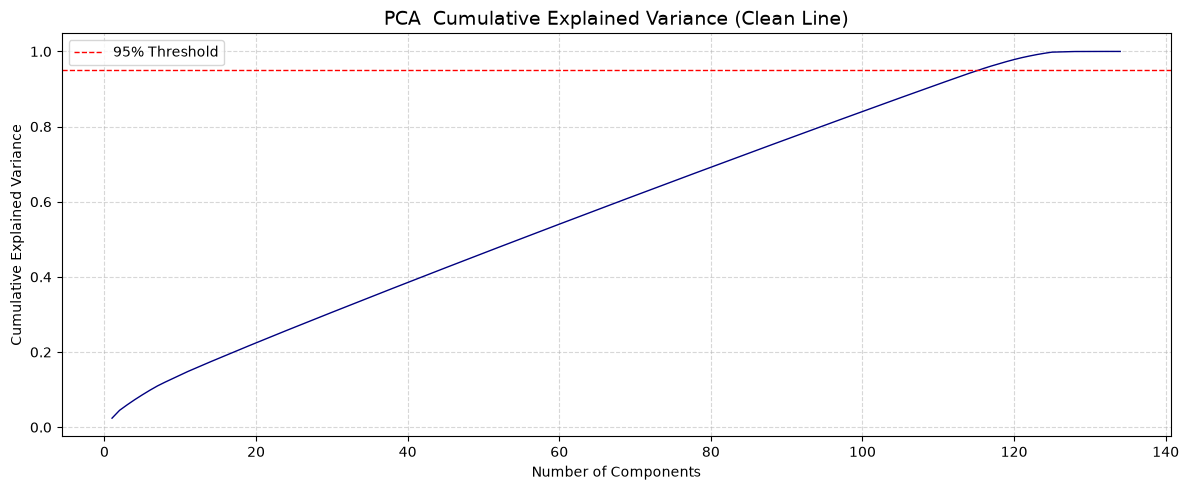

In [7]:
plt.figure(figsize=(12,5))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var,
         linewidth=1, color='navy')

plt.axhline(0.95, color='red', linestyle='--', linewidth=1,
            label='95% Threshold')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA  Cumulative Explained Variance (Clean Line)", fontsize=14)
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# **4.8 Data Engineering**

Before training our logistic regression and random forest models, it is essential to refine and optimize the feature space. Although our dataset already contains several engineered variables—such as `month_sin`, `month_cos`, and credit score ranges—additional transformations can significantly improve model performance and interpretability.

Data engineering focuses on converting raw features into representations that better capture underlying patterns. For linear models like logistic regression, this often involves scaling, encoding, and reducing multicollinearity. For tree‑based models, the goal is to enhance signal clarity, reduce noise, and ensure categorical variables are represented efficiently.

In this section, we introduce a unified data‑engineering pipeline that prepares the dataset for both modeling approaches. This includes:

- Cleaning and normalizing numeric features  
- Encoding categorical variables  
- Creating domain‑specific interaction features  
- Handling skewed distributions  
- Improving credit‑related signals  
- Ensuring consistency across train/test splits  

The result is a refined feature matrix that enhances predictive power for both logistic regression and random forest models, forming a strong foundation for the modeling chapters that follow.


# 4.9.1 Feature Engineering

To enhance the predictive power of both our logistic regression and random forest models, we introduce a small but meaningful set of engineered features. These features capture important interactions, ratios, and behavioral signals that are not directly present in the raw dataset but are highly relevant for credit‑risk modeling.

The goal is not to overwhelm the model with excessive transformations, but rather to add a focused set of features that improve signal quality while maintaining interpretability. The engineered variables include:

- **Installment‑to‑income ratio** — measures repayment pressure relative to income  
- **Credit score range** — captures uncertainty or spread in credit scoring  
- **Score × income interaction** — amplifies the effect of strong credit profiles  
- **Loan cost pressure** — combines loan size and interest rate into a single risk metric  
- **High utilization flag** — identifies borrowers with potentially risky credit behavior  
- **Short employment tenure flag** — highlights borrowers with unstable employment history  

These features enrich the dataset and provide both linear and tree‑based models with additional structure to learn from. The resulting feature matrix will be used in the modeling sections that follow.


In [ ]:
# 4.9.1 FEATURE ENGINEERING

import numpy as np
import pandas as pd


# Use the correct dataset (X from your modeling workflow)

df_fe = X.copy()

print("Original shape:", df_fe.shape)


# 1. Installment-to-income ratio

df_fe['installment_income_ratio'] = (
    df_fe['monthly_installment_usd'] / df_fe['annual_income_usd']
)
df_fe['installment_income_ratio'] = df_fe['installment_income_ratio'].replace(
    [np.inf, -np.inf], np.nan
)


# 2. Credit score range

df_fe['credit_score_range'] = (
    df_fe['credit_score_high'] - df_fe['credit_score_low']
)


# 3. Credit score × income interaction

df_fe['score_income_interaction'] = (
    df_fe['credit_score_low'] * df_fe['annual_income_usd']
)


# 4. Loan amount × interest rate interaction

df_fe['loan_cost_pressure'] = (
    df_fe['requested_amount_usd'] * df_fe['interest_rate']
)


# 5. High utilization flag

df_fe['is_high_utilization'] = (
    df_fe['revolving_utilization'] > 80
).astype(int)


# 6. Short employment tenure flag

df_fe['is_short_tenure'] = df_fe['employment_tenure'].isin(
    ['< 1 year', '1 year']
).astype(int)

print("New shape after feature engineering:", df_fe.shape)




Original shape: (85000, 21)
New shape after feature engineering: (85000, 27)


In [13]:
df_fe.columns


Index(['requested_amount_usd', 'repayment_term', 'monthly_installment_usd',
       'risk_grade_detail', 'employment_tenure', 'housing_status',
       'annual_income_usd', 'income_verification_status', 'loan_purpose',
       'region_code', 'debt_to_income_ratio', 'credit_score_low',
       'credit_score_high', 'open_credit_lines', 'public_records_count',
       'interest_rate', 'revolving_utilization', 'origination_year',
       'origination_month_num', 'month_sin', 'month_cos',
       'installment_income_ratio', 'credit_score_range',
       'score_income_interaction', 'loan_cost_pressure', 'is_high_utilization',
       'is_short_tenure'],
      dtype='str')

In [12]:
X_lineal.shape

(85000, 125)